<a href="https://colab.research.google.com/github/lolndo/Basic_Networks2/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%D0%9E%D0%B1%D1%83%D1%87%D0%B0%D1%8E%D1%89%D0%B0%D1%8F%2C_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BE%D1%87%D0%BD%D0%B0%D1%8F_%D0%B8_%D1%82%D0%B5%D1%81%D1%82%D0%BE%D0%B2%D0%B0%D1%8F_%D0%B2%D1%8B%D0%B1%D0%BE%D1%80%D0%BA%D0%B8_%D0%9F%D0%B5%D1%80%D0%B5%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%9D%D0%A1_%D0%94%D0%97_Ultra_Pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Используя базу "Пассажиры автобуса", подготовьте данные для обучения нейронной сети, классифицирующей изображение на два класса:
- входящий пассажир
- выходящий пассажир

Добейтесь точности работы модели на проверочной выборке не ниже 85%

Ссылка на датасет: https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip

Информацию о загрузке изображений и преобразовании их в numnpy-массивы вы можете найти в Базе знаний:


In [ ]:
# Ваше решение

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

!wget -q https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip -O bus.zip
!unzip -q bus.zip -d /content/bus
DATA_DIR = '/content/bus/'

replace /content/bus/Входящий/01009.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A N


In [3]:
IMG_SIZE = (128, 128)
classes = ['Входящий', 'Выходящий']
class_to_idx = {cls: i for i, cls in enumerate(classes)}

X, y = [], []
for cls in classes:
    folder = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('png', 'jpg', 'jpeg')):
            path = os.path.join(folder, fname)
            img = mpimg.imread(path)
            if img.ndim == 2:
                img = np.stack([img]*3, axis=-1)
            elif img.shape[-1] == 4:
                img = img[..., :3]
            # Изменяем размер
            from PIL import Image
            img = np.array(Image.fromarray((img*255).astype(np.uint8)).resize(IMG_SIZE)) / 255.0
            X.append(img)
            y.append(class_to_idx[cls])

X = np.array(X)
y = np.array(y)
print(f"Загружено изображений: {X.shape[0]}, форма: {X.shape[1:]}")

Загружено изображений: 9081, форма: (128, 128, 3)


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (7264, 128, 128, 3), Val: (1817, 128, 128, 3)


In [5]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
# Для валидации без аугментации
val_datagen = ImageDataGenerator()

batch_size = 32
train_generator = datagen.flow(X_train, y_train, batch_size=batch_size, shuffle=True)
val_generator   = val_datagen.flow(X_val, y_val, batch_size=batch_size, shuffle=False)

In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')          # бинарная классификация
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // batch_size,
    epochs=20,
    validation_data=val_generator,
    validation_steps=len(X_val) // batch_size
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 42s 156ms/step - accuracy: 0.7602 - loss: 0.5141 - val_accuracy: 0.7991 - val_loss: 0.4311
Epoch 2/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 34s 148ms/step - accuracy: 0.8111 - loss: 0.4107 - val_accuracy: 0.8326 - val_loss: 0.3688
Epoch 3/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 32s 142ms/step - accuracy: 0.8334 - loss: 0.3773 - val_accuracy: 0.8499 - val_loss: 0.3107
Epoch 4/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 33s 146ms/step - accuracy: 0.8453 - loss: 0.3425 - val_accuracy: 0.8644 - val_loss: 0.2979
Epoch 5/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.8588 - loss: 0.3156 - val_accuracy: 0.8800 - val_loss: 0.2608
Epoch 6/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 34s 149ms/step - accuracy: 0.8756 - loss: 0.2856 - val_accuracy: 0.8733 - val_loss: 0.2722
Epoch 7/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 32s 142ms/step - accuracy: 0.8817 - loss: 0.2708 - val_accuracy: 0.9023 - val_loss: 0.2214
Epoch 8/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 33s 147ms/step - accuracy: 0.8830 - loss: 0

Точность на проверке: 96.09%


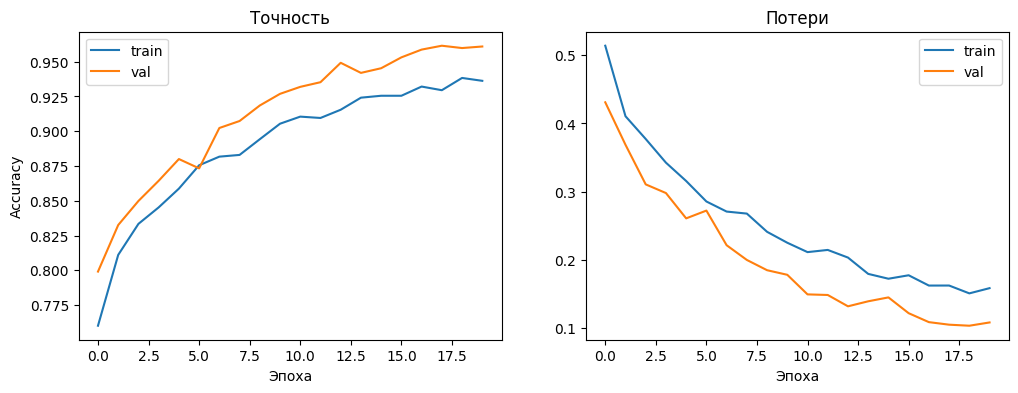

In [7]:
# Точность на проверочной выборке
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"Точность на проверке: {val_acc:.2%}")

# Графики
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Точность'); plt.xlabel('Эпоха'); plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Потери'); plt.xlabel('Эпоха')
plt.legend()
plt.show()